# Task 2 – Low-Compute ECG Artefact Identification

For this task, I will implement a **feature-based, unsupervised method for identifying artefact-corrupted ECG segments**. The aim is to use simple signal properties and threshold-based rules instead of a trained machine-learning classifier, to make the approach suitable for low-power wearable devices.

## Common ECG Artefacts

The main artefacts considered in this implementation are:

1. **Loose lead / electrode disconnection**  
   A loose or disconnected electrode can result in a nearly flat signal, large baseline excursions, and intermittent signal loss.

2. **50/60 Hz power-line interference**  
   It may be caused by electromagnetic interference, or disconnection in the driven-right-leg circuitry.

3. **Baseline wander**  
   Commonly caused by respiration, body movement, or changes in electrode-skin impedance.

4. **Muscle tremor / EMG artefact**  
   Skeletal-muscle activity introduces irregular high-frequency components into the ECG.

5. **Neuromodulation artefact**  
   Implanted electrical stimulation devices, such as neurostimulators, can introduce periodic pulses into the recorded ECG.

6. **Arterial pulse artefact**  
   Mechanical pulsation can affect an electrode positioned close to a strongly pulsating artery producing repetitive disturbances.

## ECG Frequency Content

The frequency content required from an ECG depends on the intended application. Diagnostic ECG systems generally require a wider bandwidth than monitoring systems. In this implementation, the useful ECG band is considered to extend approximately from **0.05 Hz to 100 Hz**, while particular sub-bands are analysed to identify different types of artefacts.

## Proposed Approach

The ECG signal will be divided into short segments and a small number of computationally inexpensive features will be calculated for each segment. These features include:

- Signal RMS / energy
- Low-frequency energy for baseline wander
- 50/60 Hz energy for power-line interference
- High-frequency energy for muscle artefact
- Simple QRS/R-peak consistency measurements

The resulting feature values will be compared against predefined or experimentally derived thresholds to classify each ECG segment as either:

**VALID** or **CORRUPTED**


In [57]:
!pip install wfdb matplotlib scipy numpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Sampling frequency: 360 Hz
Number of samples: 21600
Duration: 60.00 s


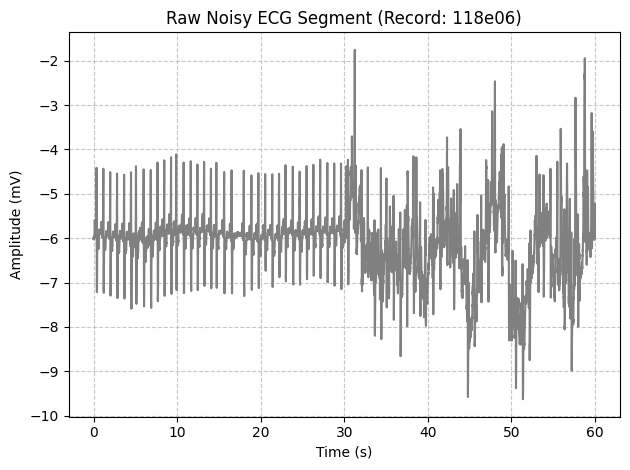

In [58]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt

# Load the data from PhysioNet
# 118e06 has 6dB noise
# Sample rate is 360Hz according to the dataset
# Since the noise is occuring after 5min according to the dataset
# Taking from 4.5min to 5.5min time period into consideration
record = wfdb.rdrecord('118e06', pn_dir='nstdb/1.0.0', sampfrom=97200, sampto=118800)

# Extract the signal and the sampling frequency
ecg_signal = record.p_signal[:, 0]  # First ECG lead/channel
fs = record.fs                      # Sampling frequency (360 Hz)
time = np.arange(len(ecg_signal)) / fs # time array in seconds

print(f"Sampling frequency: {fs} Hz")
print(f"Number of samples: {len(ecg_signal)}")
print(f"Duration: {len(ecg_signal)/fs:.2f} s")

fig, ax = plt.subplots()

ax.plot(time, ecg_signal, color='gray');
ax.set_title(f'Raw Noisy ECG Segment (Record: {record.record_name})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (mV)')
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [59]:
# Implement functions to measure properties of the ECG segment

# Bandpass Filter
def bandpass_filter(signal, lowcut, highcut, fs, order=2):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

# Signal features related to frequencies
def signalFeatures(ecg):
    x = np.asarray(ecg, dtype=float)

    # Remove DC
    x = x - np.mean(x)

    # 1. Signal RMS
    rms = np.sqrt(np.mean(x ** 2))

    # 2. Check if there is no energy in the ECG band, if there is not it should be an electrode is disconnected
    ecg_band = bandpass_filter(ecg, 0.5, 100, fs)
    ecg_energy = np.mean(ecg_band ** 2)

    # 3. Check for too much baseline wander (Could be an electrode is connected)
    baseline_band = bandpass_filter(ecg, 0.05, 0.5, fs)
    baseline_energy = np.mean(baseline_band ** 2)
    baseline_ratio = baseline_energy / (ecg_energy + 1e-12)

    # 4. Check for power line noise (50Hz and 60Hz)
    powerline50_band = bandpass_filter(ecg, 48, 52, fs)
    powerline60_band = bandpass_filter(ecg, 58, 62, fs)
    powerline_energy = max(np.mean(powerline50_band ** 2), np.mean(powerline60_band ** 2))
    powerline_ratio = powerline_energy / (ecg_energy + 1e-12)

    # 5. Check for muscle tremor
    # ECG      : 0.5Hz - 30Hz (mostly)
    # HF noise : 30Hz - 45Hz
    highfreq_band = bandpass_filter(ecg, 0.5, 30, fs)
    lowfreq_band = bandpass_filter(ecg, 30, 45, fs)

    lowfreq_energy = np.mean(lowfreq_band ** 2)
    highfreq_energy = np.mean(highfreq_band ** 2)

    highfreq_ratio = highfreq_energy / (lowfreq_energy + 1e-12)

    return rms, baseline_ratio, powerline_ratio, highfreq_ratio

In [60]:
# Get 5s ECG segments 
segment_duration = 5
segment_samples = int(segment_duration * fs)

# 4.5 min = 270 seconds
start_time = 270

# Calculate number of 5s segments betwenn 4.5min to 5.5min
num_segments = len(ecg_signal) // segment_samples

print(
    "Segment | Time (s)     |  RMS     | "
    "Baseline Ratio | Powerline Ratio | HF Ratio"
)

print("-" * 100)

for i in range(num_segments):

    start = i * segment_samples
    end = start + segment_samples

    ecg_segment = ecg_signal[start:end]

    rms, baseline_ratio, powerline_ratio, highfreq_ratio = signalFeatures(ecg_segment)

    start_time = start_time + i * segment_duration
    end_time = start_time + segment_duration

    print(
        f"{i + 1:7d} | "
        f"{start_time:4.0f} -{end_time:4.0f} s | "
        f"{rms:8.4f} | "
        f"{baseline_ratio:14.4f} | "
        f"{powerline_ratio:15.4f} | "
        f"{highfreq_ratio:8.4f}"
    )

Segment | Time (s)     |  RMS     | Baseline Ratio | Powerline Ratio | HF Ratio
----------------------------------------------------------------------------------------------------
      1 |  270 - 275 s |   0.4113 |         0.0122 |          0.0004 |  67.4270
      2 |  275 - 280 s |   0.4784 |         0.0258 |          0.0004 |  60.9347
      3 |  285 - 290 s |   0.3984 |         0.0207 |          0.0002 |  65.0220
      4 |  300 - 305 s |   0.3560 |         0.0075 |          0.0001 |  65.7665
      5 |  320 - 325 s |   0.3449 |         0.1235 |          0.0003 |  60.5274
      6 |  345 - 350 s |   0.3640 |         0.0062 |          0.0002 |  62.1026
      7 |  375 - 380 s |   0.8428 |         0.4149 |          0.0003 | 114.8290
      8 |  410 - 415 s |   0.6816 |         0.5039 |          0.0003 | 108.6504
      9 |  450 - 455 s |   0.8501 |         1.0294 |          0.0003 | 109.0476
     10 |  495 - 500 s |   1.1292 |         2.0530 |          0.0003 | 130.5403
     11 |  545 - 55

In [61]:
# Function to calculate the overall score for the ECG segment
def calculateECGScore(rms, baseline_ratio, powerline_ratio, highfreq_ratio):

    # Thresholds should be fine tuned by calculating and comapring all the data in the dataset
    # The below thresholds were assumed according to the above output
    MIN_RMS = 0.30
    MAX_BASELINE_RATIO = 1.0
    MAX_POWERLINE_RATIO = 0.001
    MAX_HIGHFREQ_RATIO = 100.0

    score = 100.0
    detected_problems = []

    # Loose / disconnected electrode
    if rms < MIN_RMS:
        severity = (MIN_RMS - rms) / MIN_RMS
        severity = min(severity, 1.0)
        score -= severity * 25
        detected_problems.append("Possible loose/disconnected electrode")

    # Baseline wander
    if baseline_ratio > MAX_BASELINE_RATIO:
        severity = (baseline_ratio - MAX_BASELINE_RATIO) / MAX_BASELINE_RATIO
        severity = min(severity, 1.0)
        score -= severity * 25
        detected_problems.append("Baseline wander")

    # Power-line interference
    if powerline_ratio > MAX_POWERLINE_RATIO:
        severity = (powerline_ratio - MAX_POWERLINE_RATIO) / MAX_POWERLINE_RATIO
        severity = min(severity, 1.0)
        score -= severity * 25
        detected_problems.append("Power line interference")

    # Muscle tremour
    if highfreq_ratio > MAX_HIGHFREQ_RATIO:
        severity = (highfreq_ratio - MAX_HIGHFREQ_RATIO) / MAX_HIGHFREQ_RATIO
        severity = min(severity, 1.0)
        score -= severity * 25
        detected_problems.append("Muscle tremor")

    score = max(score, 0)

    if len(detected_problems) == 0:
        label = "VALID"
    else:
        label = "CORRUPTED"

    return score, label, detected_problems

      1 |  600- 605 s |   0.4113 |         0.0122 |          0.0004 |  67.4270 | Score: 100.0 | VALID
Detected problems: []


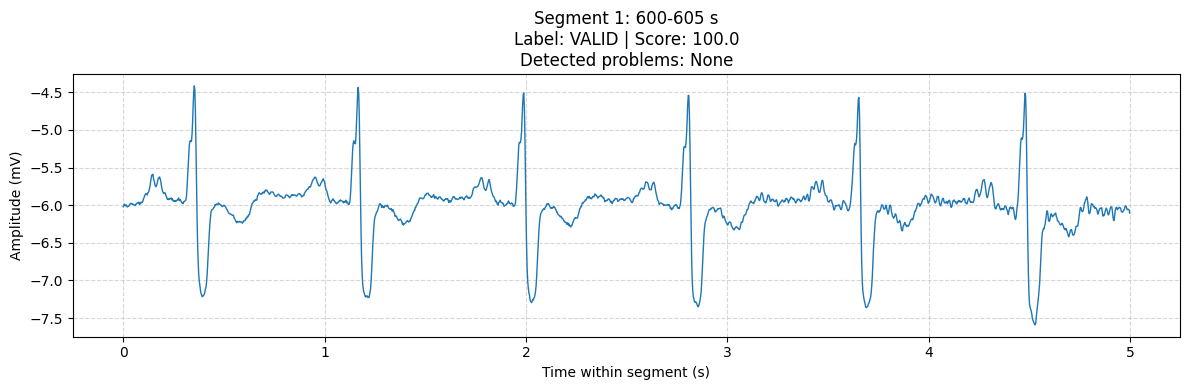

      2 |  605- 610 s |   0.4784 |         0.0258 |          0.0004 |  60.9347 | Score: 100.0 | VALID
Detected problems: []


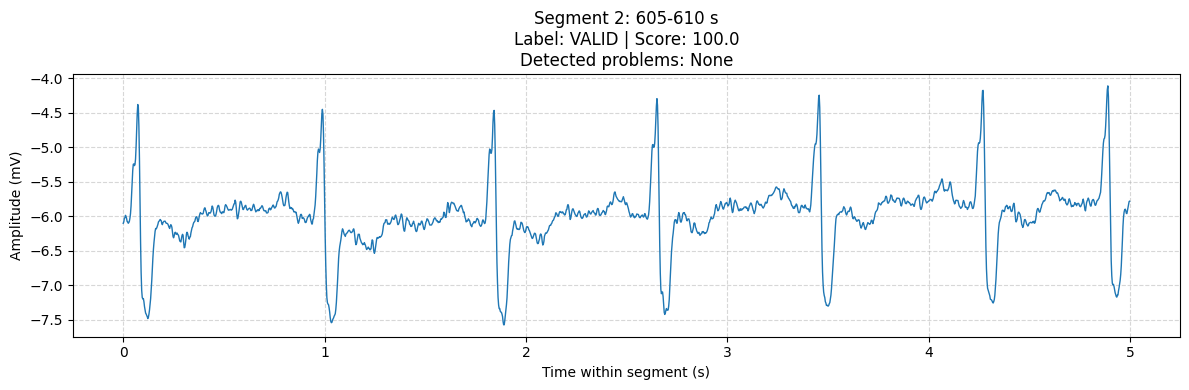

      3 |  615- 620 s |   0.3984 |         0.0207 |          0.0002 |  65.0220 | Score: 100.0 | VALID
Detected problems: []


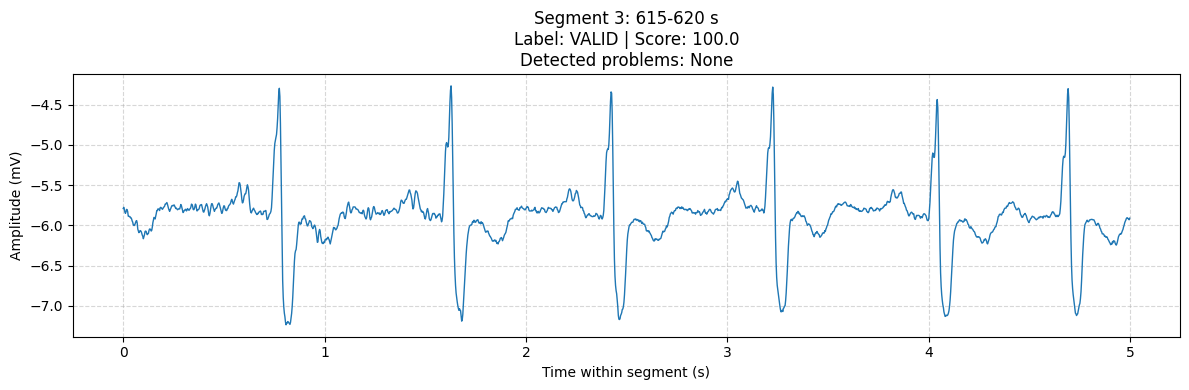

      4 |  630- 635 s |   0.3560 |         0.0075 |          0.0001 |  65.7665 | Score: 100.0 | VALID
Detected problems: []


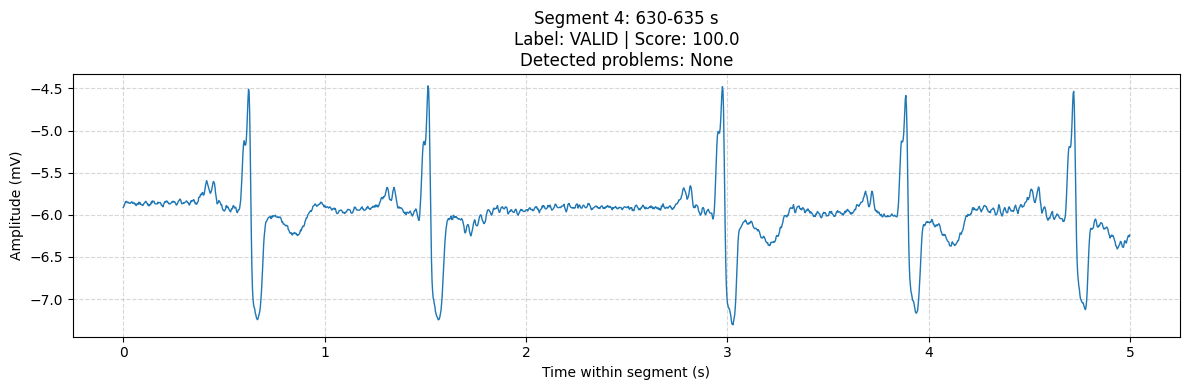

      5 |  650- 655 s |   0.3449 |         0.1235 |          0.0003 |  60.5274 | Score: 100.0 | VALID
Detected problems: []


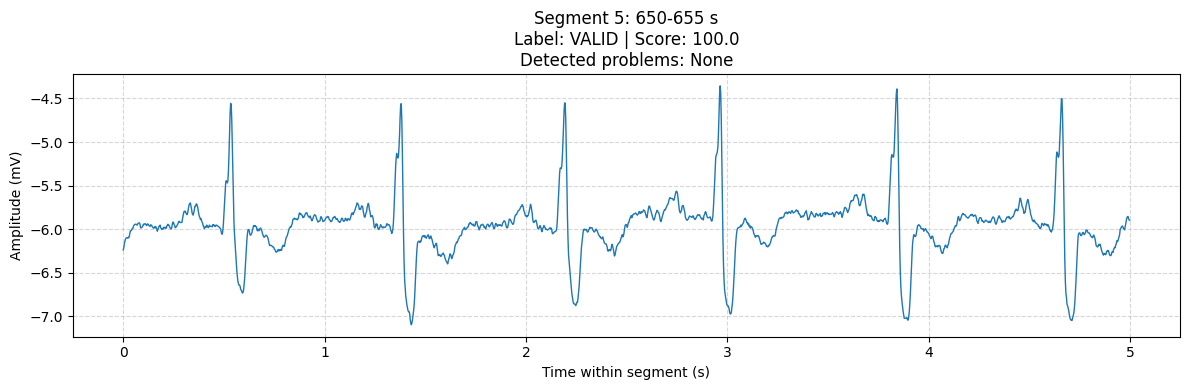

      6 |  675- 680 s |   0.3640 |         0.0062 |          0.0002 |  62.1026 | Score: 100.0 | VALID
Detected problems: []


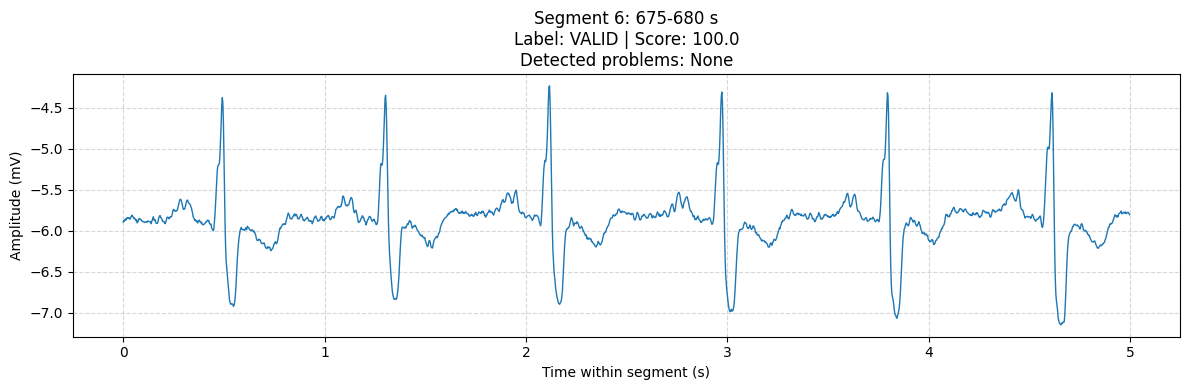

      7 |  705- 710 s |   0.8428 |         0.4149 |          0.0003 | 114.8290 | Score: 96.3 | CORRUPTED
Detected problems: ['Muscle tremor']


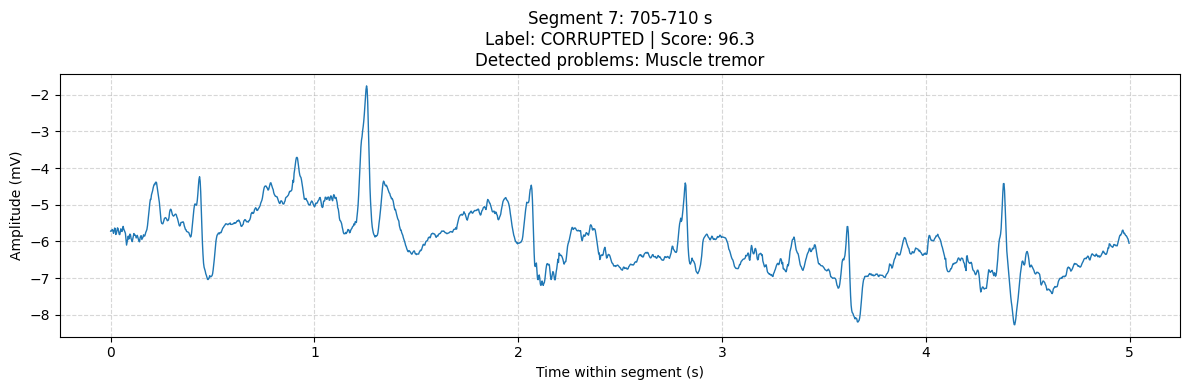

      8 |  740- 745 s |   0.6816 |         0.5039 |          0.0003 | 108.6504 | Score: 97.8 | CORRUPTED
Detected problems: ['Muscle tremor']


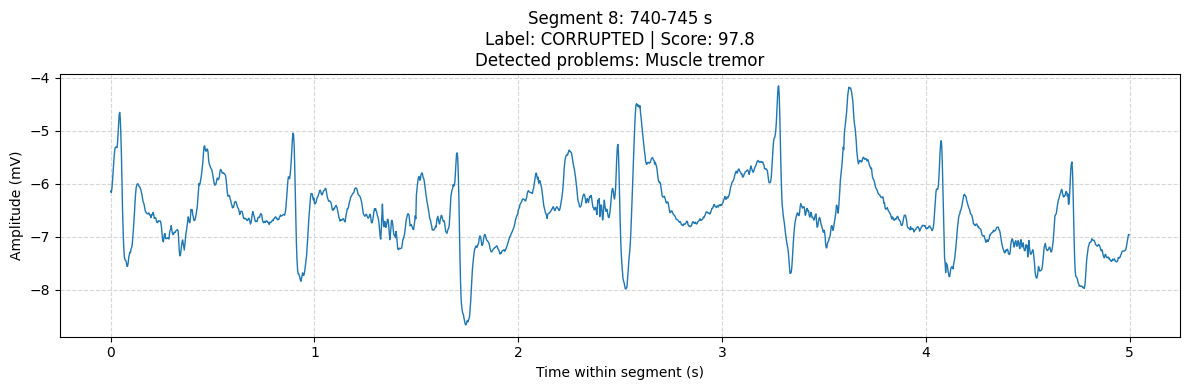

      9 |  780- 785 s |   0.8501 |         1.0294 |          0.0003 | 109.0476 | Score: 97.0 | CORRUPTED
Detected problems: ['Baseline wander', 'Muscle tremor']


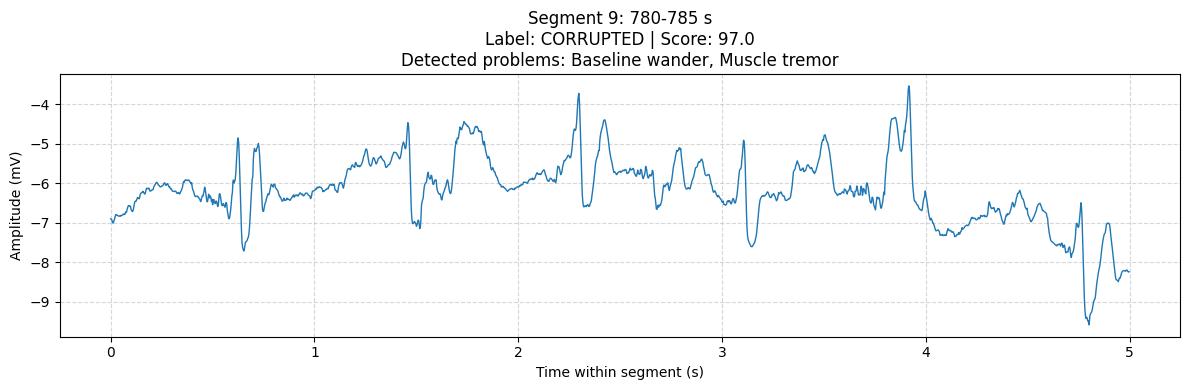

     10 |  825- 830 s |   1.1292 |         2.0530 |          0.0003 | 130.5403 | Score: 67.4 | CORRUPTED
Detected problems: ['Baseline wander', 'Muscle tremor']


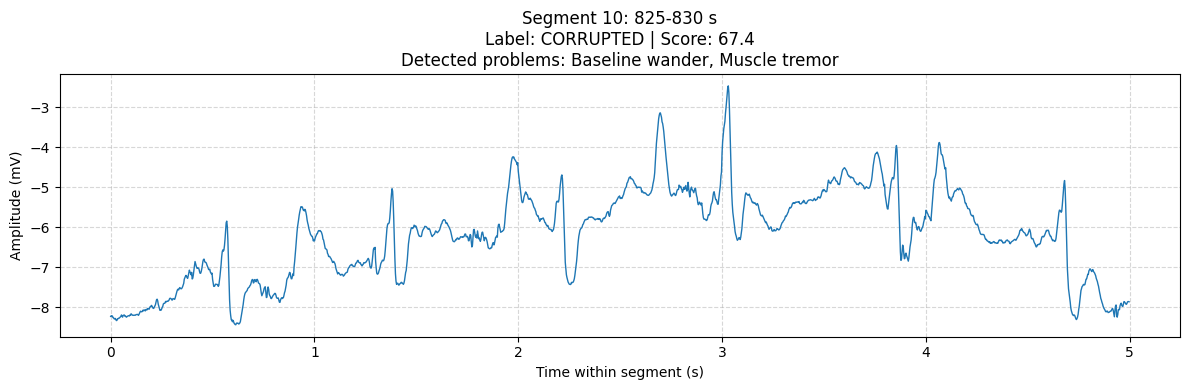

     11 |  875- 880 s |   1.0479 |         1.2812 |          0.0006 |  76.0583 | Score: 93.0 | CORRUPTED
Detected problems: ['Baseline wander']


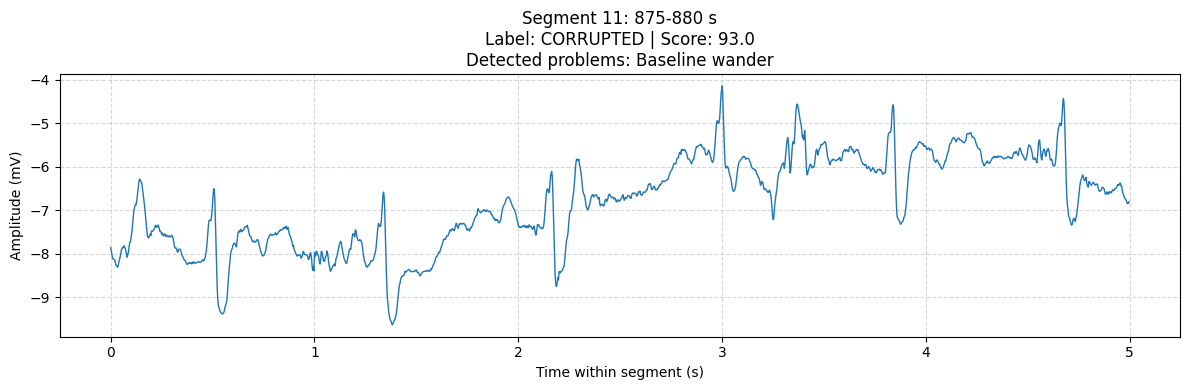

     12 |  930- 935 s |   1.1196 |         0.1284 |          0.0002 | 257.6805 | Score: 75.0 | CORRUPTED
Detected problems: ['Muscle tremor']


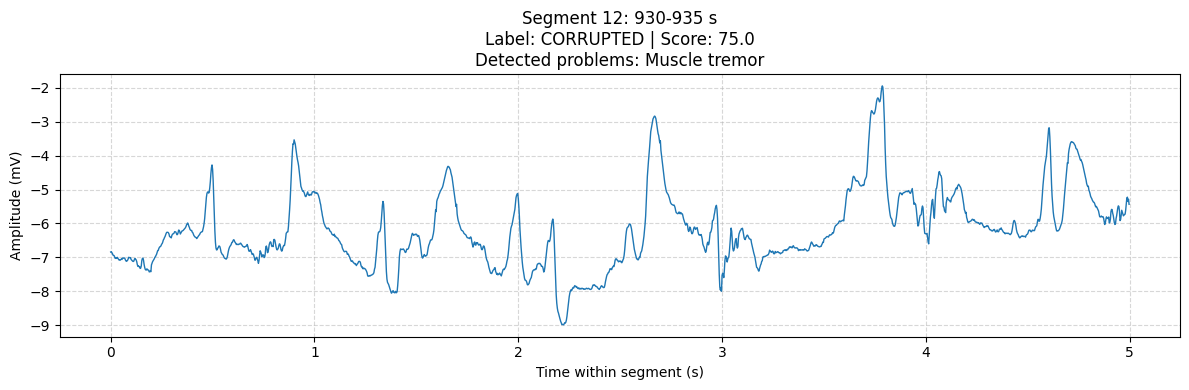

In [62]:
# Get 5 sec segments and do both signalFeatures() and calculateECGScore() then plot each segment.

for i in range(num_segments):

    start = i * segment_samples
    end = start + segment_samples

    ecg_segment = ecg_signal[start:end]

    rms, baseline_ratio, powerline_ratio, highfreq_ratio = signalFeatures(ecg_segment)
    score, label, detected_problems = calculateECGScore(rms, baseline_ratio, powerline_ratio, highfreq_ratio)

    start_time = start_time + i * segment_duration
    end_time = start_time + segment_duration

    print(
        f"{i + 1:7d} | "
        f"{start_time:4.0f}-{end_time:4.0f} s | "
        f"{rms:8.4f} | "
        f"{baseline_ratio:14.4f} | "
        f"{powerline_ratio:15.4f} | "
        f"{highfreq_ratio:8.4f} | "
        f"Score: {score:.1f} | "
        f"{label}"
    )

    print("Detected problems:", detected_problems)
    time = np.arange(len(ecg_segment)) / fs

    plt.figure(figsize=(12, 4))

    plt.plot(
        time,
        ecg_segment,
        linewidth=1
    )

    # Convert detected problem list into readable text
    if detected_problems:
        problems_text = ", ".join(detected_problems)
    else:
        problems_text = "None"

    plt.title(
        f"Segment {i + 1}: "
        f"{start_time:.0f}-{end_time:.0f} s\n"
        f"Label: {label} | Score: {score:.1f}\n"
        f"Detected problems: {problems_text}"
    )

    plt.xlabel("Time within segment (s)")
    plt.ylabel("Amplitude (mV)")

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

For segments like Segment 4 I propose an R peak detection algorithm to count the R peaks inside the segment. And also we can then find the time distance between consecutive R peaks. According to these 2 data we can make decisions whether the signal is corrupted because of a neuromodulation or arterial pulse tapping artifact.

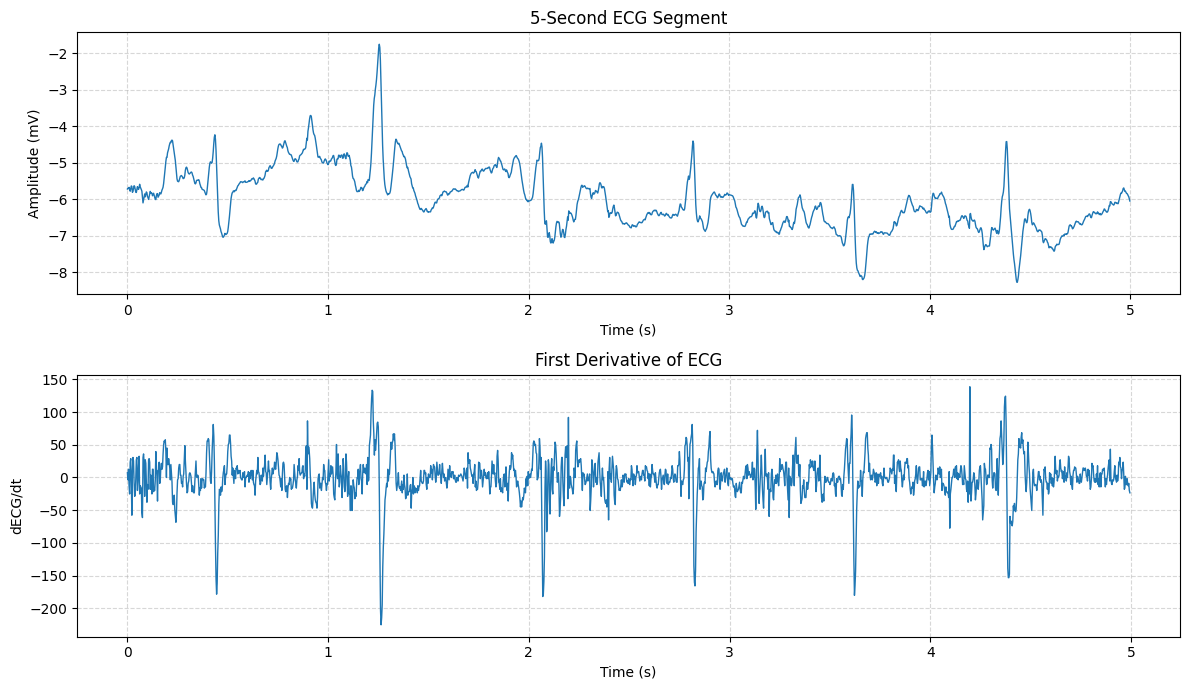

In [63]:
# I started implementing an algorithm like Pan-tompkins but with less complexity to identify R peaks.
# Calculating the 1st derivative of the ECG signal.

segment_duration = 5  # seconds
start = int((300-270) * fs)
N = int(segment_duration * fs)
end = start + N

ecg_segment = ecg_signal[start:end]

time = np.arange(N) / fs

# Calculate first derivative of the ECG signal
derivative = np.diff(ecg_segment) * fs

# Time vector for derivative
time_derivative = time[:-1]

# ============================================================
# Plot ECG and first derivative
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Original ECG
axes[0].plot(
    time,
    ecg_segment,
    linewidth=1
)

axes[0].set_title("5-Second ECG Segment")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# First derivative
axes[1].plot(
    time_derivative,
    derivative,
    linewidth=1
)

axes[1].set_title("First Derivative of ECG")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("dECG/dt")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Computational Complexity Compared to a Simple ML Classifier

The proposed method is designed to have a low and predictable computational cost so that it can run continuously on a battery-powered wearable device.

For a sampling frequency of **360 Hz** and a segment duration of **5 s**, each ECG segment contains:

$$
360 \times 5 = 1800 \text{ samples}
$$

### Computational Cost of the Proposed Method

The proposed method mainly consists of:

- Second-order IIR bandpass filtering
- Squaring and accumulating samples to estimate signal energy
- RMS calculation
- Energy-ratio calculations
- Simple threshold comparisons

The current implementation uses approximately six frequency bands:

1. ECG band: 0.5–100 Hz
2. Baseline-wander band: 0.05–0.5 Hz
3. 50 Hz power-line band
4. 60 Hz power-line band
5. Normal ECG band: 0.5–30 Hz
6. High-frequency band: 30–45 Hz

A second-order bandpass filter implemented using second-order sections (SOS) requires only a small number of multiplications and additions for each incoming ECG sample. A rough estimate for the complete filter bank is on the order of:

$$
2 \times (5 + 4) = 18
$$

arithmetic operations per ecg sample.

For all six filters:

$$
6 \times 18 = 108
$$

operations are required per input sample.

For a 5-second ECG segment:

$$
108 \times 1800 = 194,400
$$

operations are required.

Therefore, the filtering stage requires approximately **194,000 arithmetic operations per 5-second segment**, or approximately **39,000 operations per second**. This computational load is small for a modern low-power microcontroller and can be processed continuously as ECG samples arrive. Additional operations required for RMS, energy accumulation, ratios, and threshold comparisons are small compared with the filtering operations.

### Memory Requirement

For an embedded implementation, the filters can operate **sample-by-sample**, while the signal energies can be accumulated continuously. Therefore, it is not necessary to store the complete 5-second ECG segment in memory.

Only filter states, coefficients, energy accumulators, and threshold values need to be stored. Therefore, the working memory requirement can be kept below a few kilobytes.

No trained model parameters need to be stored.

### Comparison with a Lightweight ML Classifier

A lightweight machine-learning approach such as a 1-D CNN operating directly on ECG samples will require hundreds of thousands to millions of multiply-accumulate operations for every input window. It also requires memory for:

- Model weights
- Intermediate activation buffers
- Input buffers
- Model inference code

An illustrative comparison is shown below:

| Property | Proposed Feature-Based Method | Lightweight 1-D CNN |
|---|---:|---:|
| Input samples per 5 s | 1800 | 1800 |
| Computation | ~\(10^5\) arithmetic operations/window | ~\(10^5-10^6+\) MACs/window |
| Model weights | None | Required |
| Training | Not required | Required |
| Working memory | Very low | Higher |
| Interpretability | High | Lower |
| Real-time streaming | Simple | Model dependent |
| Reason for rejection | Directly identifiable | Often less transparent |

The exact computational cost of an ML classifier depends strongly on its architecture. An extremely small linear classifier could require fewer operations than the proposed filter bank; therefore, it would not be correct to claim that every ML method is computationally more expensive.

However, for classifiers operating directly on raw ECG data, the proposed feature-based approach has several advantages for a wearable system. Its computation is fixed and predictable, it requires no model storage or training, and each rejection decision can be directly related to a physical property of the ECG signal.

Therefore, the proposed method trades some artefact-detection capability for **lower implementation complexity, predictable computational load, low memory usage, and high interpretability**, which are desirable properties for continuous operation on a low-power microcontroller.


## Artifacts that can be missed in this approach

The proposed system is most sensitive to gross signal loss, baseline drift, 50/60 Hz power-line interference, and increased high-frequency energy. Because it does not explicitly analyse ECG morphology or QRS complexes, artefacts whose spectral content overlaps normal ECG activity may remain undetected. In particular, arterial pulse artefacts, intermittent electrode-contact disturbances, and some neuromodulation artefacts may not significantly alter the selected energy ratios. Short transient artefacts may also be deluted when features are averaged across a five-second window. The method therefore trades artefact-detection coverage for low computational and memory requirements.
